In [19]:
# Wind suitability analysis setup
# 1) Use wind speed raster instead of solar PVOUT: C:/HyGalapagos/inputs/wind-speed_100m_galapagos_clipped.tif
# 2) Add distance-to-poblados as a constraint where closer settlements are less suitable and farther areas are better.
#    Use populated areas vector: C:/Galapagos_IERSE/poblados/poblado_68a9d757b1b9ed0b86e3d58153578f13.shp
# 3) Use the wind land-cover remap: C:/HyGalapagos/inputs/remap_eolico_fuzzy.csv


In [20]:
# Inputs: fill these paths and numeric values before running the analysis.
# Keep everything in a projected CRS with meter units (for distance and area).

INPUTS = {
    "galapagos_boundary": "C:/Galapagos_IERSE/01_Organizacion_Territorial/Parroquias_Galapagos_CONALI_2018.shp",      # Polygon boundary (shp/gpkg/geojson)
    "wind_speed_raster": "C:/HyGalapagos/inputs/wind-speed_100m_galapagos_clipped.tif",  # Wind speed raster
    "dem": "C:/Galapagos_IERSE/dem_30m.tif",       # DEM raster used to derive terrain suitability
    "roads": "C:/Galapagos_IERSE/01_Vialidad/Red_vial_Galapagos_OSM_2023.shp",                   # Roads vector
    "substations": "C:/Galapagos_IERSE/subestaciones.shp",             # Substations vector
    "poblados": "C:/Galapagos_IERSE/poblados/poblado_68a9d757b1b9ed0b86e3d58153578f13.shp",  # Population centers / settlements
    "land_cover": "C:/Galapagos_IERSE/cobertura/A_ECOSISTEMAS_NATIVOS_2016.shp",
    "land_cover_remap": "C:/HyGalapagos/inputs/remap_eolico_fuzzy.csv",
}

PARAMS = {
    "threshold": 0.7,                    # Fuzzy suitability threshold in [0, 1]
    "land_cover_field": "FROM",         # Field in land-cover layer containing classes used in remap_eolico_fuzzy.csv
    "analysis_crs": "EPSG:32715",       # Projected CRS in meters for distance and slope analysis
    "wind_midpoint": 8.0,                # Sigmoid center for wind speed fuzzy membership (example value; tune if needed)
    "wind_steepness": 0.8,               # Sigmoid steepness for wind speed fuzzy membership
    "slope_midpoint_deg": 12.0,          # Sigmoid center for slope fuzzy membership
    "slope_steepness": 0.35,             # Sigmoid steepness for slope fuzzy membership
    "roads_max_distance_m": 20000.0,     # Linear decrease: 1 at 0 m -> 0 at this distance
    "substations_max_distance_m": 15000.0,  # Linear decrease: 1 at 0 m -> 0 at this distance
    "poblados_max_distance_m": 10000.0,  # Linear increase: 0 at 0 m -> 1 at this distance (farther from settlements is better)
}

WEIGHTS = {
    "wind": 0.45,                     # Example: 0.45
    "terrain": 0.20,                  # Example: 0.10
    "roads": 0.10,                    # Example: 0.10
    "substations": 0.05,              # Example: 0.10
    "landuse": 0.15,                  # Example: 0.15 (from land-cover fuzzy remap)
    "poblados": 0.05,                 # Example: 0.10 (farther from settlements is better)
}

OUTPUTS = {
    "dem_clipped": "C:/HyGalapagos/outputs_eolico/dem_clipped.tif",
    "slope_degrees": "C:/HyGalapagos/outputs_eolico/slope_degrees.tif",
    "terrain_reclass": "C:/HyGalapagos/outputs_eolico/terrain_reclass.tif",
    "wind_reclass": "C:/HyGalapagos/outputs_eolico/wind_reclass.tif",
    "roads_distance": "C:/HyGalapagos/outputs_eolico/roads_distance.tif",
    "roads_reclass": "C:/HyGalapagos/outputs_eolico/roads_reclass.tif",
    "substations_distance": "C:/HyGalapagos/outputs_eolico/substations_distance.tif",
    "substations_reclass": "C:/HyGalapagos/outputs_eolico/substations_reclass.tif",
    "poblados_distance": "C:/HyGalapagos/outputs_eolico/poblados_distance.tif",
    "poblados_reclass": "C:/HyGalapagos/outputs_eolico/poblados_reclass.tif",
    "land_cover_reclass": "C:/HyGalapagos/outputs_eolico/land_cover_reclass.tif",

    "weighted_suitability": "C:/HyGalapagos/outputs_eolico/weighted_suitability.tif",

    "candidate_raster": "C:/HyGalapagos/outputs_eolico/candidate_raster.tif",
        "candidate_polygons": "C:/HyGalapagos/outputs_eolico/candidate_polygons.gpkg",
}


In [21]:
import csv
import re
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.features import rasterize, shapes
from rasterio.warp import calculate_default_transform, reproject
from rasterio.features import geometry_mask
from scipy.ndimage import distance_transform_edt, find_objects, label
from pathlib import Path
from datetime import datetime


In [22]:
def _save_raster(path, array, template_profile, nodata_value=-9999.0):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    profile = template_profile.copy()
    profile.update(
        dtype="float32",
        count=1,
        compress="lzw",
        nodata=nodata_value,
    )
    data = np.where(np.isfinite(array), array, nodata_value).astype("float32")

    with rasterio.open(p, "w", **profile) as dst:
        dst.write(data, 1)
    return str(p)


def _polygonize_candidates(candidate_array, transform, crs):
    features = []
    for geom, val in shapes(candidate_array, transform=transform):
        if val == 1:
            features.append({"geometry": geom, "properties": {"suitability": 1}})

    if not features:
        return gpd.GeoDataFrame({"suitability": [], "area_m2": []}, geometry=[], crs=crs)

    gdf = gpd.GeoDataFrame.from_features(features, crs=crs)
    gdf["area_m2"] = gdf.geometry.area
    return gdf


In [23]:
def run_wind_suitability(inputs, params, weights, outputs):
    _require_non_empty(inputs, "INPUTS")
    _require_non_empty(outputs, "OUTPUTS")
    _validate_weights(weights)
    if params.get("threshold") is None:
        raise ValueError("PARAMS['threshold'] is empty.")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_outputs = {k: _with_timestamp_label(v, timestamp) for k, v in outputs.items()}
    outputs.update(run_outputs)

    analysis_crs = params.get("analysis_crs", "EPSG:32715")
    projected_dem_profile = _project_raster_profile(inputs["dem"], analysis_crs)

    # DEM defines the projected analysis grid and is clipped to Galapagos boundary with NoData outside.
    dem_projected = _reproject_to_template(inputs["dem"], projected_dem_profile, resampling=Resampling.bilinear)
    transform = projected_dem_profile["transform"]
    crs = projected_dem_profile["crs"]
    shape = (projected_dem_profile["height"], projected_dem_profile["width"] )
    boundary = gpd.read_file(inputs["galapagos_boundary"]).to_crs(crs)
    dem_clipped = _clip_array_to_boundary(dem_projected, transform, boundary)
    outputs["dem_clipped"] = _save_raster(outputs["dem_clipped"], dem_clipped, projected_dem_profile)

    # Slope and fuzzy terrain suitability derived from clipped DEM.
    slope_degrees = _slope_from_dem(dem_clipped, transform)
    terrain_reclass = _fuzzy_sigmoid_decreasing(
        slope_degrees,
        midpoint=float(params["slope_midpoint_deg"] ),
        steepness=float(params["slope_steepness"] ),
    )

    # Load, project, and clip vectors to match the projected DEM CRS.
    roads = gpd.clip(gpd.read_file(inputs["roads"]).to_crs(crs), boundary)
    substations = gpd.clip(gpd.read_file(inputs["substations"]).to_crs(crs), boundary)
    poblados = gpd.clip(gpd.read_file(inputs["poblados"]).to_crs(crs), boundary)
    land_cover = gpd.read_file(inputs["land_cover"]).to_crs(crs)

    # Land-cover fuzzy suitability: apply direct membership values from remap table.
    land_cover_remap = _load_land_cover_remap(inputs["land_cover_remap"])
    land_cover_field = _detect_land_cover_field(
        land_cover,
        land_cover_remap,
        preferred_field=params.get("land_cover_field"),
    )
    land_cover_reclass = _rasterize_land_cover_reclass(
        land_cover,
        out_shape=shape,
        transform=transform,
        remap_dict=land_cover_remap,
        class_field=land_cover_field,
    )
    land_cover_reclass = _clip_array_to_boundary(land_cover_reclass, transform, boundary)

    # Wind speed fuzzy membership: sigmoidal increasing.
    wind_speed = _reproject_to_template(inputs["wind_speed_raster"], projected_dem_profile, resampling=Resampling.bilinear)
    wind_speed_clip = _clip_array_to_boundary(wind_speed, transform, boundary)
    wind_reclass = _fuzzy_sigmoid_increasing(
        wind_speed_clip,
        midpoint=float(params["wind_midpoint"] ),
        steepness=float(params["wind_steepness"] ),
    )

    # Distance rasters per-island and fuzzy memberships with linear curves.
    roads_raster = _rasterize_features(roads, out_shape=shape, transform=transform)
    sub_raster = _rasterize_features(substations, out_shape=shape, transform=transform)
    poblados_raster = _rasterize_features(poblados, out_shape=shape, transform=transform)
    boundary_mask = np.isfinite(dem_clipped)

    roads_dist = _distance_within_boundary_components(roads_raster, boundary_mask, transform)
    sub_dist = _distance_within_boundary_components(sub_raster, boundary_mask, transform)
    poblados_dist = _distance_within_boundary_components(poblados_raster, boundary_mask, transform)

    roads_reclass = _fuzzy_linear_decreasing(
        roads_dist,
        max_distance=float(params["roads_max_distance_m"] ),
    )
    substations_reclass = _fuzzy_linear_decreasing(
        sub_dist,
        max_distance=float(params["substations_max_distance_m"] ),
    )
    poblados_reclass = _fuzzy_linear_increasing(
        poblados_dist,
        max_distance=float(params["poblados_max_distance_m"] ),
    )

    # Islands without substations receive lowest fuzzy membership for substation criterion.
    no_substation_pixels = boundary_mask & ~np.isfinite(sub_dist)
    substations_reclass[no_substation_pixels] = 0.0

    # If a settlement is absent in an island, those cells get the lowest score for this constraint.
    no_poblados_pixels = boundary_mask & ~np.isfinite(poblados_dist)
    poblados_reclass[no_poblados_pixels] = 0.0

    # Weighted fuzzy overlay.
    suitability = _weighted_sum(
        wind_s=wind_reclass,
        terrain_s=terrain_reclass,
        roads_s=roads_reclass,
        sub_s=substations_reclass,
        landuse_s=land_cover_reclass,
        poblados_s=poblados_reclass,
        weights=weights,
    )

    # Threshold selection for candidate sites in fuzzy [0, 1] space.
    threshold = float(params["threshold"] )
    candidate = np.where(suitability >= threshold, suitability, np.nan).astype("float32")

    # Save raster outputs.
    outputs["slope_degrees"] = _save_raster(outputs["slope_degrees"], slope_degrees, projected_dem_profile)
    outputs["terrain_reclass"] = _save_raster(outputs["terrain_reclass"], terrain_reclass, projected_dem_profile)
    outputs["wind_reclass"] = _save_raster(outputs["wind_reclass"], wind_reclass, projected_dem_profile)
    outputs["roads_distance"] = _save_raster(outputs["roads_distance"], roads_dist, projected_dem_profile)
    outputs["roads_reclass"] = _save_raster(outputs["roads_reclass"], roads_reclass, projected_dem_profile)
    outputs["substations_distance"] = _save_raster(outputs["substations_distance"], sub_dist, projected_dem_profile)
    outputs["substations_reclass"] = _save_raster(outputs["substations_reclass"], substations_reclass, projected_dem_profile)
    outputs["poblados_distance"] = _save_raster(outputs["poblados_distance"], poblados_dist, projected_dem_profile)
    outputs["poblados_reclass"] = _save_raster(outputs["poblados_reclass"], poblados_reclass, projected_dem_profile)
    outputs["land_cover_reclass"] = _save_raster(outputs["land_cover_reclass"], land_cover_reclass, projected_dem_profile)
    outputs["weighted_suitability"] = _save_raster(outputs["weighted_suitability"], suitability, projected_dem_profile)
    outputs["candidate_raster"] = _save_raster(outputs["candidate_raster"], candidate, projected_dem_profile)

    # Polygonize candidate sites and add area in square meters.
    candidates_gdf = _polygonize_candidates(candidate, transform=transform, crs=crs)
    out_vector = Path(outputs["candidate_polygons"] )
    out_vector.parent.mkdir(parents=True, exist_ok=True)

    if str(out_vector).lower().endswith(".shp"):
        candidates_gdf.to_file(out_vector)
    else:
        candidates_gdf.to_file(out_vector, driver="GPKG")

    return {

        "timestamp": timestamp,

        "threshold": threshold,

        "n_candidate_polygons": len(candidates_gdf),

        "total_candidate_area_m2": float(candidates_gdf["area_m2"].sum()) if len(candidates_gdf) else 0.0,

        "land_cover_field_used": land_cover_field,        
        "analysis_crs": str(crs),
        "roads_distance_output": outputs["roads_distance"],        
        "candidate_polygons_output": outputs["candidate_polygons"],

        "substations_distance_output": outputs["substations_distance"],        
        "weighted_suitability_output": outputs["weighted_suitability"],
        "poblados_distance_output": outputs["poblados_distance"],
    }

In [24]:
# Memory-safe distance accumulation for large grids.
# It adaptively downsamples the binary feature raster for EDT and upsamples back to the full grid.
def _distance_to_features(feature_raster, transform, max_cells=25_000_000):
    pixel_size_y = abs(transform.e)
    pixel_size_x = abs(transform.a)
    feature_mask = feature_raster == 1
    if not np.any(feature_mask):
        raise ValueError("No feature pixels found after rasterization.")

    height, width = feature_raster.shape
    total_cells = height * width
    factor = int(np.ceil(np.sqrt(total_cells / max_cells))) if total_cells > max_cells else 1

    if factor <= 1:
        distance = distance_transform_edt(
            ~feature_mask,
            sampling=(pixel_size_y, pixel_size_x),
        )
        return distance.astype("float32")

    # Max-pool to preserve any feature pixel in coarse blocks.
    coarse_h = int(np.ceil(height / factor))
    coarse_w = int(np.ceil(width / factor))
    pad_h = coarse_h * factor - height
    pad_w = coarse_w * factor - width
    padded = np.pad(
        feature_mask,
        ((0, pad_h), (0, pad_w)),
        mode="constant",
        constant_values=False,
    )
    coarse_mask = padded.reshape(coarse_h, factor, coarse_w, factor).max(axis=(1, 3))

    coarse_distance = distance_transform_edt(
        ~coarse_mask,
        sampling=(pixel_size_y * factor, pixel_size_x * factor),
    ).astype("float32")

    # Nearest-neighbor upsample back to original shape.
    distance = np.repeat(np.repeat(coarse_distance, factor, axis=0), factor, axis=1)
    distance = distance[:height, :width]
    return distance.astype("float32")

{'timestamp': '20260824_165143', 'threshold': 0.7, 'n_candidate_polygons': 0, 'total_candidate_area_m2': 0.0, 'land_cover_field_used': 'Ecosis_Nat', 'analysis_crs': 'EPSG:32715', 'roads_distance_output': 'C:\\HyGalapagos\\outputs_eolico\\roads_distance_20260824_165143.tif', 'candidate_polygons_output': 'C:\\HyGalapagos\\outputs_eolico\\candidate_polygons_20260824_165143.gpkg', 'substations_distance_output': 'C:\\HyGalapagos\\outputs_eolico\\substations_distance_20260824_165143.tif', 'weighted_suitability_output': 'C:\\HyGalapagos\\outputs_eolico\\weighted_suitability_20260824_165143.tif', 'poblados_distance_output': 'C:\\HyGalapagos\\outputs_eolico\\poblados_distance_20260824_165143.tif'}


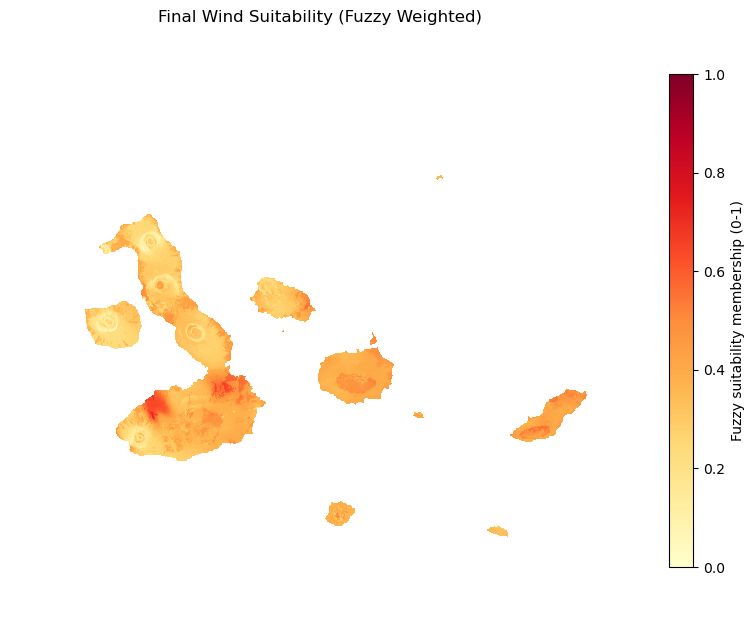

In [25]:
# Run analysis and visualize final fuzzy suitability map.
result = run_wind_suitability(INPUTS, PARAMS, WEIGHTS, OUTPUTS)
print(result)

import matplotlib.pyplot as plt
import rasterio

with rasterio.open(OUTPUTS["weighted_suitability"]) as src:
    suitability = src.read(1).astype("float32")
    nodata = src.nodata
    if nodata is not None:
        suitability[suitability == nodata] = np.nan

plt.figure(figsize=(10, 8))
im = plt.imshow(suitability, cmap="YlOrRd", vmin=0.0, vmax=1.0)
plt.title("Final Wind Suitability (Fuzzy Weighted)")
plt.axis("off")
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label("Fuzzy suitability membership (0-1)")
plt.show()

In [27]:
# Diagnostics for CRS and output ranges.
inspect_paths = [
    OUTPUTS["dem_clipped"],
    OUTPUTS["roads_distance"],
    OUTPUTS["roads_reclass"],
    OUTPUTS["substations_distance"],
    OUTPUTS["substations_reclass"],
    OUTPUTS["poblados_distance"],
    OUTPUTS["poblados_reclass"],
    OUTPUTS["wind_reclass"],
    OUTPUTS["weighted_suitability"],
]

for inspect_path in inspect_paths:
    with rasterio.open(inspect_path) as src:
        arr = src.read(1).astype("float32")
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        finite = arr[np.isfinite(arr)]
        unique_vals = np.unique(finite) if finite.size else np.array([])
        print(inspect_path)
        print("  crs:", src.crs)
        print("  transform:", src.transform)
        print("  min/max:", float(np.nanmin(arr)), float(np.nanmax(arr)))

        print("  unique sample:", unique_vals[:10])        
        print("  unique count:", len(unique_vals))

C:\HyGalapagos\outputs_eolico\dem_clipped_20260824_165143.tif
  crs: EPSG:32715
  transform: | 30.84, 0.00, 609729.81|
| 0.00,-30.84, 10114873.86|
| 0.00, 0.00, 1.00|
  min/max: -11.12828540802002 1701.6466064453125
  unique sample: [-11.128285   -9.698484   -9.062243   -8.499104   -7.3204355  -6.999312
  -6.7856197  -6.393971   -6.227801   -6.222126 ]
  unique count: 7821386
C:\HyGalapagos\outputs_eolico\roads_distance_20260824_165143.tif
  crs: EPSG:32715
  transform: | 30.84, 0.00, 609729.81|
| 0.00,-30.84, 10114873.86|
| 0.00, 0.00, 1.00|
  min/max: 0.0 45988.921875
  unique sample: [  0.        30.843044  43.618652  61.68609   68.96714   87.237305
  92.52913   97.53427  111.20618  123.37218 ]
  unique count: 371339
C:\HyGalapagos\outputs_eolico\roads_reclass_20260824_165143.tif
  crs: EPSG:32715
  transform: | 30.84, 0.00, 609729.81|
| 0.00,-30.84, 10114873.86|
| 0.00, 0.00, 1.00|
  min/max: 0.0 1.0
  unique sample: [0.0000000e+00 1.7881393e-07 8.5234642e-06 1.3291836e-05 1.686811

In [ ]:
# Check substation coverage by individual boundary polygons (islands).
analysis_crs = PARAMS.get("analysis_crs", "EPSG:32715")
boundary_check = gpd.read_file(INPUTS["galapagos_boundary"]).to_crs(analysis_crs)
substations_check = gpd.read_file(INPUTS["substations"]).to_crs(analysis_crs)

islands = boundary_check.explode(index_parts=False).reset_index(drop=True)
islands["island_id"] = islands.index + 1
join = gpd.sjoin(substations_check, islands[["island_id", "geometry"]], how="left", predicate="within")
counts = join.groupby("island_id").size()

print("Total substations:", len(substations_check))
print("Substations inside boundary polygons:", int(counts.sum()))
print("Islands with >=1 substation:", int(counts.index.nunique()))
print("Total island polygons:", len(islands))
print("Island IDs without substations:", [i for i in islands["island_id"].tolist() if i not in set(counts.index.tolist())][:25])

Total substations: 12
Substations inside boundary polygons: 12
Islands with >=1 substation: 7
Total island polygons: 235
Island IDs without substations: [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


In [ ]:
# Debug: verify point rasterization and substation class distribution.
analysis_crs = PARAMS.get("analysis_crs", "EPSG:32715")
projected_dem_profile = _project_raster_profile(INPUTS["dem"], analysis_crs)
dem_projected = _reproject_to_template(INPUTS["dem"], projected_dem_profile, resampling=Resampling.bilinear)
transform = projected_dem_profile["transform"]
crs = projected_dem_profile["crs"]
shape = (projected_dem_profile["height"], projected_dem_profile["width"])
boundary = gpd.read_file(INPUTS["galapagos_boundary"]).to_crs(crs)
dem_clipped = _clip_array_to_boundary(dem_projected, transform, boundary)
boundary_mask = np.isfinite(dem_clipped)

substations_dbg = gpd.clip(gpd.read_file(INPUTS["substations"]).to_crs(crs), boundary)
sub_raster_dbg = _rasterize_features(substations_dbg, out_shape=shape, transform=transform)
sub_dist_dbg = _distance_within_boundary_components(sub_raster_dbg, boundary_mask, transform)
sub_reclass_dbg = _classify_substations(sub_dist_dbg)

print("Substation points after clip:", len(substations_dbg))
print("Burned substation pixels:", int((sub_raster_dbg == 1).sum()))
finite_sub = sub_reclass_dbg[np.isfinite(sub_reclass_dbg)]
vals, counts = np.unique(finite_sub, return_counts=True)
print("Substation reclass classes and counts:", dict(zip(vals.astype(int).tolist(), counts.tolist())))
print("Min/max substation distance (m):", float(np.nanmin(sub_dist_dbg)), float(np.nanmax(sub_dist_dbg)))

NameError: name '_classify_substations' is not defined

: 

In [ ]:
# Debug: sample substation reclass at substation point locations.
sub_reclass_path = OUTPUTS["substations_reclass"]
sub_points = gpd.clip(gpd.read_file(INPUTS["substations"]).to_crs(PARAMS.get("analysis_crs", "EPSG:32715")), gpd.read_file(INPUTS["galapagos_boundary"]).to_crs(PARAMS.get("analysis_crs", "EPSG:32715")))

coords = [(geom.x, geom.y) for geom in sub_points.geometry if geom is not None and not geom.is_empty]
with rasterio.open(sub_reclass_path) as src:
    values = [v[0] for v in src.sample(coords)]
    nodata = src.nodata

vals = np.array(values, dtype="float32")
if nodata is not None:
    vals[vals == nodata] = np.nan
print("Substation point count:", len(coords))
print("Reclass values at points:", vals.tolist())
print("Unique point classes:", np.unique(vals[np.isfinite(vals)]))

Substation point count: 12
Reclass values at points: [5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]
Unique point classes: [5.]


In [ ]:
# Compare base vs suffixed substation distance/reclass outputs.
check_files = [
    r"C:/HyGalapagos/outputs_solar/substations_distance.tif",
    r"C:/HyGalapagos/outputs_solar/substations_distance_run1.tif",
    r"C:/HyGalapagos/outputs_solar/substations_distance_run2.tif",
    r"C:/HyGalapagos/outputs_solar/substations_reclass.tif",
    r"C:/HyGalapagos/outputs_solar/substations_reclass_run1.tif",
    r"C:/HyGalapagos/outputs_solar/substations_reclass_run2.tif",
]

for p in check_files:
    with rasterio.open(p) as src:
        a = src.read(1).astype("float32")
        if src.nodata is not None:
            a[a == src.nodata] = np.nan
        print(p)
        print("  min/max:", float(np.nanmin(a)), float(np.nanmax(a)))
        vals = np.unique(a[np.isfinite(a)])
        print("  unique sample:", vals[:8], "count:", len(vals))

C:/HyGalapagos/outputs_solar/substations_distance.tif
  min/max: 0.0 131363.546875
  unique sample: [  0.       92.52913 130.85596 185.05826 206.90143 261.7119  277.5874
 292.6028 ] count: 275126
C:/HyGalapagos/outputs_solar/substations_distance_run1.tif
  min/max: 0.0 130424.265625
  unique sample: [ 0.       30.843044 43.618652 61.68609  68.96714  87.237305 92.52913
 97.53427 ] count: 2021024
C:/HyGalapagos/outputs_solar/substations_distance_run2.tif
  min/max: 0.0 130424.265625
  unique sample: [ 0.       30.843044 43.618652 61.68609  68.96714  87.237305 92.52913
 97.53427 ] count: 2021024
C:/HyGalapagos/outputs_solar/substations_reclass.tif
  min/max: 1.0 5.0
  unique sample: [1. 2. 3. 4. 5.] count: 5
C:/HyGalapagos/outputs_solar/substations_reclass_run1.tif
  min/max: 1.0 5.0
  unique sample: [1. 2. 3. 4. 5.] count: 5
C:/HyGalapagos/outputs_solar/substations_reclass_run2.tif
  min/max: 1.0 5.0
  unique sample: [1. 2. 3. 4. 5.] count: 5


In [ ]:
# Verify substation distance equals 0 at point locations for the latest output path.
latest_sub_dist = result.get("substations_distance_output", OUTPUTS["substations_distance"])
sub_points_latest = gpd.clip(
    gpd.read_file(INPUTS["substations"]).to_crs(PARAMS.get("analysis_crs", "EPSG:32715")),
    gpd.read_file(INPUTS["galapagos_boundary"]).to_crs(PARAMS.get("analysis_crs", "EPSG:32715")),
)

coords_latest = [(geom.x, geom.y) for geom in sub_points_latest.geometry if geom is not None and not geom.is_empty]
with rasterio.open(latest_sub_dist) as src:
    vals_latest = np.array([v[0] for v in src.sample(coords_latest)], dtype="float32")
    if src.nodata is not None:
        vals_latest[vals_latest == src.nodata] = np.nan

print("Latest distance file:", latest_sub_dist)
print("Distances at substation points (m):", vals_latest.tolist())
print("Min/Max at substation points (m):", float(np.nanmin(vals_latest)), float(np.nanmax(vals_latest)))

Latest distance file: C:\HyGalapagos\outputs_solar\substations_distance_run2.tif
Distances at substation points (m): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Min/Max at substation points (m): 0.0 0.0


In [ ]:
# Verify new rule: boundary pixels without substation distance are assigned class 1.
latest_sub_dist = result.get("substations_distance_output", OUTPUTS["substations_distance"])
latest_sub_reclass = OUTPUTS["substations_reclass"]

analysis_crs = PARAMS.get("analysis_crs", "EPSG:32715")
profile_check = _project_raster_profile(INPUTS["dem"], analysis_crs)
dem_check = _reproject_to_template(INPUTS["dem"], profile_check, resampling=Resampling.bilinear)
boundary_check = gpd.read_file(INPUTS["galapagos_boundary"]).to_crs(profile_check["crs"])
mask_check = np.isfinite(_clip_array_to_boundary(dem_check, profile_check["transform"], boundary_check))

with rasterio.open(latest_sub_dist) as src_d, rasterio.open(latest_sub_reclass) as src_r:
    d = src_d.read(1).astype("float32")
    r = src_r.read(1).astype("float32")
    if src_d.nodata is not None:
        d[d == src_d.nodata] = np.nan
    if src_r.nodata is not None:
        r[r == src_r.nodata] = np.nan

no_sub_pixels = mask_check & ~np.isfinite(d)
assigned_one = np.sum((r == 1) & no_sub_pixels)
total_no_sub = np.sum(no_sub_pixels)

print("Latest substation distance file:", latest_sub_dist)
print("Latest substation reclass file:", latest_sub_reclass)
print("No-substation boundary pixels:", int(total_no_sub))
print("Those pixels assigned class 1:", int(assigned_one))
print("All no-substation pixels are class 1:", bool(total_no_sub == assigned_one))

Latest substation distance file: C:\HyGalapagos\outputs_solar\substations_distance_run2_run1.tif
Latest substation reclass file: C:\HyGalapagos\outputs_solar\substations_reclass_run2_run1.tif
No-substation boundary pixels: 1627380
Those pixels assigned class 1: 1627380
All no-substation pixels are class 1: True
